In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file7803.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file303.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file13436.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file14412.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file1992.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/validation/fake/file24661.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset

In [3]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader,TensorDataset
from transformers import Wav2Vec2Processor,Wav2Vec2Model
from pathlib import Path
import torchaudio
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix
from tqdm import tqdm
import soundfile as sf

In [4]:
base_path="/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm"

In [5]:
class CustomDataset(Dataset):
    def __init__(self, base_path, split="training", sample_rate=16000, duration=4.0):
        self.sample_rate = sample_rate
        self.max_length  = int(sample_rate * duration)  # 64000
        self.files       = []
        self.labels      = []

        base_path = Path(base_path)
        skipped   = 0

        for label, cls in enumerate(["real", "fake"]):
            folder = base_path / split / cls
            wavs = sorted(folder.glob("*.wav"))

            for f in wavs:
                try:
                    # Use soundfile to validate — much more reliable than torchcodec
                    info = sf.info(str(f))
                    if info.frames > 0:
                        self.files.append(f)
                        self.labels.append(label)
                    else:
                        skipped += 1
                except:
                    skipped += 1

        print(f"[{split}] Loaded: {len(self.files)} | Skipped: {skipped} | "
              f"real={self.labels.count(0):,} fake={self.labels.count(1):,}")

    def __len__(self):
        return len(self.files)

    def _load_audio(self, path):
        try:
            data, sr = sf.read(str(path), dtype="float32", always_2d=True)
            waveform  = torch.from_numpy(data.T)  # (channels, samples)
            # Stereo → mono
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            waveform = waveform.squeeze(0)  # (samples,)
            # Resample if needed
            if sr != self.sample_rate:
                waveform = torchaudio.functional.resample(waveform, sr, self.sample_rate)
            # Pad or trim to fixed length
            n = waveform.shape[0]
            if n < self.max_length:
                waveform = torch.nn.functional.pad(waveform, (0, self.max_length - n))
            else:
                waveform = waveform[:self.max_length]
            # NEW: Normalize the waveform for Wav2Vec2
            waveform = (waveform - waveform.mean()) / torch.sqrt(waveform.var() + 1e-7)
            return waveform
        except Exception as e:
            print(f"WARNING: Failed to load {path.name}: {e}")
            return torch.zeros(self.max_length)

    def __getitem__(self, idx):
        waveform = self._load_audio(self.files[idx])
        label    = self.labels[idx]
        return waveform, torch.tensor(label, dtype=torch.long)

In [6]:
# Dataset load
train_df=CustomDataset(base_path,"training")
val_df=CustomDataset(base_path,"validation")

test_df=CustomDataset(base_path,"testing")

[training] Loaded: 53866 | Skipped: 2 | real=26,939 fake=26,927
[validation] Loaded: 10798 | Skipped: 0 | real=5,400 fake=5,398
[testing] Loaded: 4634 | Skipped: 0 | real=2,264 fake=2,370


In [7]:
train_loader=DataLoader(train_df,batch_size=16,shuffle=True,num_workers=2)
val_loader=DataLoader(val_df,batch_size=16,shuffle=False,num_workers=2)
test_loader=DataLoader(test_df,batch_size=16,shuffle=False,num_workers=2)

# Defining Model

In [8]:
class Wav2Vec2Classifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()

        
        # Load pre-trained Wav2Vec2 backbone
        self.wav2vec2 = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
        
        # FREEZE the entire backbone — only train the classifier head
        for param in self.wav2vec2.parameters():
            param.requires_grad = False
        
        # Small trainable classifier head
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, input_values):
        # input_values: (batch, samples)
        outputs = self.wav2vec2(input_values=input_values)
        
        # Mean pool across time dimension: (batch, time, 768) → (batch, 768)
        hidden_states = outputs.last_hidden_state
        pooled = hidden_states.mean(dim=1)
        
        logits = self.classifier(pooled)
        return logits

In [9]:
device=torch.device("cuda")

In [10]:
model = Wav2Vec2Classifier().to(device)
backbone = model.wav2vec2

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# ============================
# STEP 1: Pre-compute all embeddings (run once, ~15 mins)
# ============================
model.eval()
better_backbone = model.wav2vec2.to(device)

def extract_and_save_embeddings(loader, save_path):
    all_embeddings = []
    all_labels     = []

    with torch.no_grad():
        for waveforms, labels in tqdm(loader, desc=f"Extracting → {save_path}"):
            waveforms = waveforms.to(device)
            # FIXED: using better_backbone
            outputs   = better_backbone(input_values=waveforms)
            # Mean pool: (batch, time, 768) → (batch, 768)
            embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeddings.append(embeddings)
            all_labels.append(labels.numpy())

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels     = np.concatenate(all_labels,     axis=0)

    np.save(f"{save_path}_embeddings.npy", all_embeddings)
    np.save(f"{save_path}_labels.npy",     all_labels)
    print(f"Saved {all_embeddings.shape} → {save_path}")

extract_and_save_embeddings(train_loader, "/kaggle/working/train")
extract_and_save_embeddings(val_loader,   "/kaggle/working/val")
extract_and_save_embeddings(test_loader,  "/kaggle/working/test")

Extracting → /kaggle/working/train: 100%|██████████| 3367/3367 [17:14<00:00,  3.25it/s]


Saved (53866, 768) → /kaggle/working/train


Extracting → /kaggle/working/val: 100%|██████████| 675/675 [03:29<00:00,  3.22it/s]


Saved (10798, 768) → /kaggle/working/val


Extracting → /kaggle/working/test: 100%|██████████| 290/290 [01:29<00:00,  3.23it/s]

Saved (4634, 768) → /kaggle/working/test


In [12]:
def load_emb(path, batch_size, shuffle):
    X = torch.tensor(np.load(f"{path}_embeddings.npy"), dtype=torch.float32)
    y = torch.tensor(np.load(f"{path}_labels.npy"),     dtype=torch.long)
    print(f"{path.split('/')[-1]}: {X.shape}")
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)

fast_train = load_emb("/kaggle/working/train", 512, True)
fast_val   = load_emb("/kaggle/working/val",   512, False)
fast_test  = load_emb("/kaggle/working/test",  512, False)

train: torch.Size([53866, 768])
val: torch.Size([10798, 768])
test: torch.Size([4634, 768])


In [13]:
# ── Weighted loss —
real_count = train_df.labels.count(0)
fake_count = train_df.labels.count(1)
total      = real_count + fake_count
weights    = torch.tensor([total/(2*real_count), total/(2*fake_count)], dtype=torch.float32).to(device)
criterion  = nn.CrossEntropyLoss(weight=weights)
print(f"Class weights → real: {weights[0]:.3f}  fake: {weights[1]:.3f}")

Class weights → real: 1.000  fake: 1.000


In [14]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(768, 512),nn.LayerNorm(512),nn.ReLU(),nn.Dropout(0.4),

            nn.Linear(512, 256),nn.LayerNorm(256),nn.ReLU(),nn.Dropout(0.3),

            nn.Linear(256, 128),nn.ReLU(),nn.Dropout(0.2),

            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

fast_model = Classifier().to(device)
optimizer  = torch.optim.AdamW(fast_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [15]:
total = sum(p.numel() for p in fast_model.parameters())
print(f"Total params: {total:,}")

Total params: 559,746


In [16]:
EPOCHS, best_val_acc = 100, 0
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(EPOCHS):
    fast_model.train()
    preds, trues, tloss = [], [], 0
    for X, y in fast_train:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out  = fast_model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        tloss += loss.item()
        preds.extend(out.argmax(1).cpu().numpy())
        trues.extend(y.cpu().numpy())
    train_acc  = accuracy_score(trues, preds)
    train_loss = tloss / len(fast_train)

    fast_model.eval()
    preds, trues, vloss = [], [], 0
    with torch.no_grad():
        for X, y in fast_val:
            X, y = X.to(device), y.to(device)
            out   = fast_model(X)
            vloss += criterion(out, y).item()
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(y.cpu().numpy())
    val_acc  = accuracy_score(trues, preds)
    val_f1   = f1_score(trues, preds)
    val_loss = vloss / len(fast_val)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train loss:{train_loss:.4f} acc:{train_acc:.4f} | "
          f"Val loss:{val_loss:.4f} acc:{val_acc:.4f} F1:{val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(fast_model.state_dict(), "/kaggle/working/best_classifier.pth")
        print(f"   Saved (val_acc={val_acc:.4f})")

Epoch 01/100 | Train loss:0.3997 acc:0.8277 | Val loss:0.3393 acc:0.8515 F1:0.8605
   Saved (val_acc=0.8515)
Epoch 02/100 | Train loss:0.3409 acc:0.8567 | Val loss:0.3090 acc:0.8703 F1:0.8723
   Saved (val_acc=0.8703)
Epoch 03/100 | Train loss:0.3257 acc:0.8654 | Val loss:0.3081 acc:0.8679 F1:0.8740
Epoch 04/100 | Train loss:0.3116 acc:0.8718 | Val loss:0.2916 acc:0.8773 F1:0.8787
   Saved (val_acc=0.8773)
Epoch 05/100 | Train loss:0.3018 acc:0.8765 | Val loss:0.2864 acc:0.8788 F1:0.8823
   Saved (val_acc=0.8788)
Epoch 06/100 | Train loss:0.2972 acc:0.8770 | Val loss:0.2773 acc:0.8839 F1:0.8832
   Saved (val_acc=0.8839)
Epoch 07/100 | Train loss:0.2894 acc:0.8818 | Val loss:0.2811 acc:0.8817 F1:0.8857
Epoch 08/100 | Train loss:0.2816 acc:0.8847 | Val loss:0.2749 acc:0.8890 F1:0.8877
   Saved (val_acc=0.8890)
Epoch 09/100 | Train loss:0.2809 acc:0.8864 | Val loss:0.2675 acc:0.8886 F1:0.8897
Epoch 10/100 | Train loss:0.2742 acc:0.8873 | Val loss:0.2680 acc:0.8908 F1:0.8922
   Saved (val_

In [21]:
# ── Recreate y_true, y_scores, y_pred from scratch ──
import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, f1_score, accuracy_score, confusion_matrix

fast_model.load_state_dict(torch.load("/kaggle/working/best_classifier.pth"))
fast_model.eval()

# ── Test set ───────────────────────────────────────────
all_preds, all_labels_list, all_probs = [], [], []
with torch.no_grad():
    for X, y in fast_test:
        logits = fast_model(X.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels_list.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

y_true   = np.array(all_labels_list)
y_scores = np.array(all_probs)          # ← this is what was missing

# ── Val set for EER threshold ──────────────────────────
val_probs, val_true = [], []
with torch.no_grad():
    for X, y in fast_val:
        probs = torch.softmax(fast_model(X.to(device)), dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_true.extend(y.numpy())

val_probs = np.array(val_probs)
val_true  = np.array(val_true)

# ── Compute EER threshold ──────────────────────────────
fpr, tpr, thresholds = roc_curve(val_true, val_probs)
eer_val    = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
eer_thresh = float(interp1d(fpr, thresholds)(eer_val))

# ── Apply threshold ────────────────────────────────────
y_pred = (y_scores >= eer_thresh).astype(int)

print(f"y_true   : {y_true.shape}")
print(f"y_scores : {y_scores.shape}")
print(f"y_pred   : {y_pred.shape}")
print(f"eer_thresh: {eer_thresh:.4f}")
print("All variables ready ✓")

y_true   : (4634,)
y_scores : (4634,)
y_pred   : (4634,)
eer_thresh: 0.5105
All variables ready ✓


In [17]:
import numpy as np
from sklearn.metrics import f1_score
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve

# Get validation probabilities
fast_model.eval()
val_probs, val_true = [], []

with torch.no_grad():
    for X_batch, y_batch in fast_val:
        logits = fast_model(X_batch.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_true.extend(y_batch.numpy())

val_probs = np.array(val_probs)
val_true  = np.array(val_true)

# Find EER threshold specifically
fpr, tpr, thresholds = roc_curve(val_true, val_probs)
eer_val  = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
eer_thresh = float(interp1d(fpr, thresholds)(eer_val))
print(f"EER on val set : {eer_val*100:.2f}%")
print(f"EER threshold  : {eer_thresh:.4f}")

# Also find best F1 threshold
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.2, 0.8, 0.005):
    preds = (val_probs >= t).astype(int)
    score = f1_score(val_true, preds)
    if score > best_f1:
        best_f1, best_thresh = score, t
print(f"Best F1 threshold: {best_thresh:.4f}  (F1={best_f1:.4f})")

EER on val set : 8.13%
EER threshold  : 0.5035
Best F1 threshold: 0.4450  (F1=0.9200)


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Use EER threshold on test set
y_pred_eer = (y_scores >= eer_thresh).astype(int)

acc      = accuracy_score(y_true, y_pred_eer)
f1       = f1_score(y_true, y_pred_eer)
cm       = confusion_matrix(y_true, y_pred_eer)
real_acc = cm[0,0] / cm[0].sum()
fake_acc = cm[1,1] / cm[1].sum()

print("=" * 48)
print("  RESULTS WITH EER-OPTIMAL THRESHOLD")
print("=" * 48)
print(f"  Accuracy      : {acc*100:.2f}%   (need ≥ 80%)")
print(f"  EER           : {eer_val*100:.2f}%   (need ≤ 12%)")
print(f"  F1 Score      : {f1*100:.2f}%   (need ≥ 80%)")
print(f"  Real accuracy : {real_acc*100:.2f}%   (need ≥ 75%)")
print(f"  Fake accuracy : {fake_acc*100:.2f}%   (need ≥ 75%)")
print("=" * 48)

  RESULTS WITH EER-OPTIMAL THRESHOLD
  Accuracy      : 84.07%   (need ≥ 80%)
  EER           : 8.08%   (need ≤ 12%)
  F1 Score      : 85.02%   (need ≥ 80%)
  Real accuracy : 79.55%   (need ≥ 75%)
  Fake accuracy : 88.40%   (need ≥ 75%)


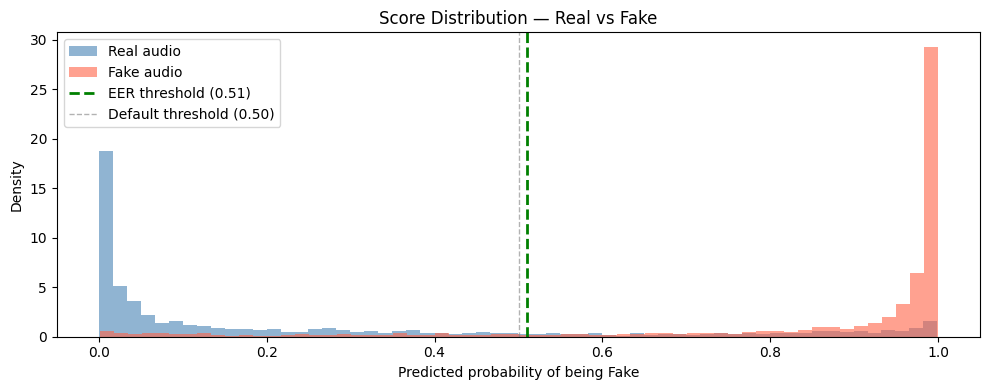

In [23]:
# ── Cell 11: Visualize score overlap 
import matplotlib.pyplot as plt

real_scores = y_scores[y_true == 0]
fake_scores = y_scores[y_true == 1]

plt.figure(figsize=(10, 4))
plt.hist(real_scores, bins=60, alpha=0.6, color='steelblue', 
         label='Real audio', density=True)
plt.hist(fake_scores, bins=60, alpha=0.6, color='tomato',    
         label='Fake audio', density=True)
plt.axvline(x=eer_thresh, color='green',  linestyle='--', 
            linewidth=2, label=f'EER threshold ({eer_thresh:.2f})')
plt.axvline(x=0.5,        color='gray',   linestyle='--', 
            linewidth=1, label='Default threshold (0.50)', alpha=0.6)
plt.xlabel('Predicted probability of being Fake')
plt.ylabel('Density')
plt.title('Score Distribution — Real vs Fake')
plt.legend()
plt.tight_layout()
plt.show()

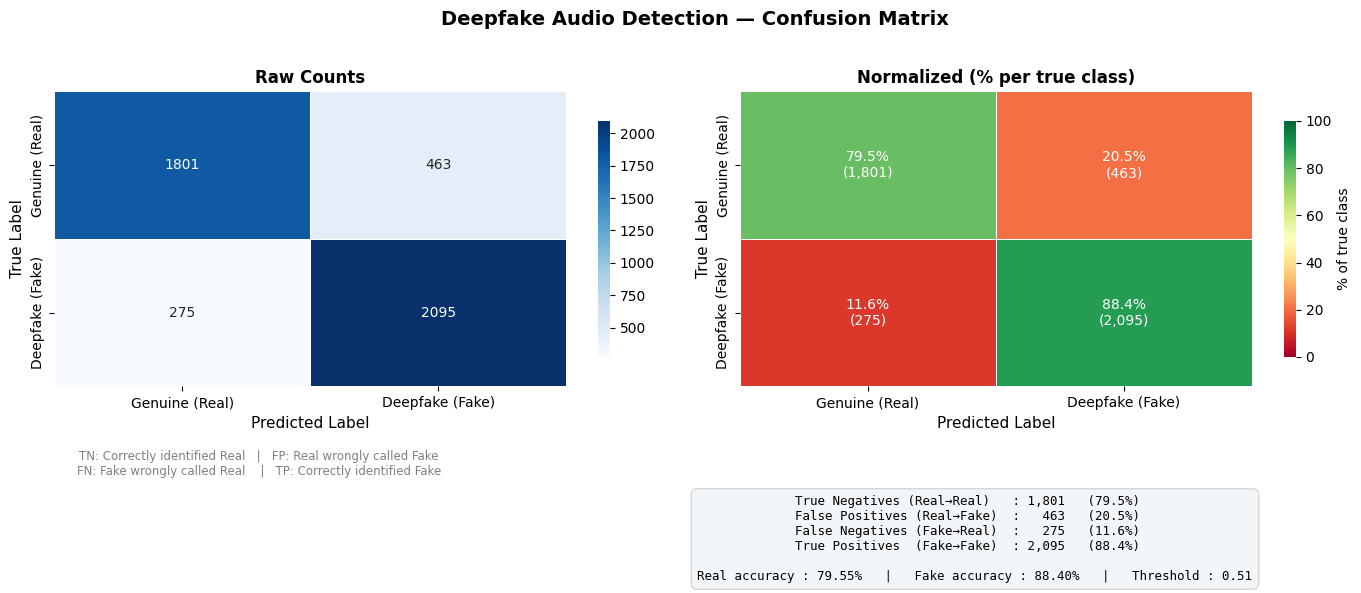

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# y_true and y_pred should already exist from your evaluation cell
# if not, re-run evaluation cell first

cm       = confusion_matrix(y_true, y_pred)
real_acc = cm[0,0] / cm[0].sum() * 100
fake_acc = cm[1,1] / cm[1].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Deepfake Audio Detection — Confusion Matrix", 
             fontsize=14, fontweight="bold", y=1.02)

# ── Plot 1: Raw counts ─────────────────────────────────
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    yticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Raw Counts", fontsize=12, fontweight="bold")
axes[0].set_ylabel("True Label",      fontsize=11)
axes[0].set_xlabel("Predicted Label", fontsize=11)

# Annotate each cell with meaning
axes[0].text(0.4, -0.3,
    f"TN: Correctly identified Real   |   FP: Real wrongly called Fake\n"
    f"FN: Fake wrongly called Real    |   TP: Correctly identified Fake",
    transform=axes[0].transAxes,
    ha="center", fontsize=8.5,
    color="gray"
)

# ── Plot 2: Percentage normalized ─────────────────────
cm_pct = cm.astype(float)
cm_pct[0] = cm_pct[0] / cm[0].sum() * 100
cm_pct[1] = cm_pct[1] / cm[1].sum() * 100

labels = np.array([
    [f"{cm_pct[0,0]:.1f}%\n({cm[0,0]:,})", f"{cm_pct[0,1]:.1f}%\n({cm[0,1]:,})"],
    [f"{cm_pct[1,0]:.1f}%\n({cm[1,0]:,})", f"{cm_pct[1,1]:.1f}%\n({cm[1,1]:,})"]
])

sns.heatmap(
    cm_pct,
    annot=labels,
    fmt="",
    cmap="RdYlGn",
    ax=axes[1],
    xticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    yticklabels=["Genuine (Real)", "Deepfake (Fake)"],
    linewidths=0.5,
    linecolor="white",
    vmin=0, vmax=100,
    cbar_kws={"shrink": 0.8, "label": "% of true class"}
)
axes[1].set_title("Normalized (% per true class)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("True Label",      fontsize=11)
axes[1].set_xlabel("Predicted Label", fontsize=11)

# ── Summary box below plots ────────────────────────────
summary = (
    f"True Negatives (Real→Real)   : {cm[0,0]:>5,}   ({cm_pct[0,0]:.1f}%)  \n"
    f"False Positives (Real→Fake)  : {cm[0,1]:>5,}   ({cm_pct[0,1]:.1f}%)  \n"
    f"False Negatives (Fake→Real)  : {cm[1,0]:>5,}   ({cm_pct[1,0]:.1f}%)  \n"
    f"True Positives  (Fake→Fake)  : {cm[1,1]:>5,}   ({cm_pct[1,1]:.1f}%)  \n\n"
    f"Real accuracy : {real_acc:.2f}%   |   Fake accuracy : {fake_acc:.2f}%   |   Threshold : {eer_thresh:.2f}"
)
fig.text(0.7, -0.12, summary, ha="center", fontsize=9,
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f4f8", 
                   edgecolor="#cccccc", alpha=0.8))

plt.tight_layout()
plt.show()

In [45]:
import json

config = {
    "threshold"   : float(eer_thresh),
    "sample_rate" : 16000,
    "duration"    : 4.0,
    "model"       : "facebook/wav2vec2-base",
    "labels"      : {"0": "Genuine (Real)", "1": "Deepfake (AI-Generated)"}
}
with open("/kaggle/working/config.json", "w") as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))

{
  "threshold": 0.5104758116703305,
  "sample_rate": 16000,
  "duration": 4.0,
  "model": "facebook/wav2vec2-base",
  "labels": {
    "0": "Genuine (Real)",
    "1": "Deepfake (AI-Generated)"
  }
}
